In [278]:
import os
from skimage import color, io, measure, img_as_ubyte, segmentation, morphology
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom
import math
from skimage.util import img_as_float
from skimage.util import img_as_ubyte
from skimage.filters import threshold_otsu, median, gaussian, prewitt_h, prewitt_v, prewitt
from skimage.color import rgb2gray, label2rgb
from scipy.ndimage import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm
from scipy.spatial import distance

In [279]:
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.imshow(original)
    ax1.set_title("Original")
    ax1.axis("off")
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis("off")
    io.show()

## Reading Dicom


In [280]:
in_dir = "example_images/"
im_name = "1-442.dcm"
ds = dicom.dcmread(in_dir + im_name)
print(ds)
im = ds.pixel_array

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 174
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 61.7.148187188172271071649499494197343400503
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.34'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['DERIVED', 'SECONDARY']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 61.7.148187188172271071649499494197343400503
(0008,0020) Study Date                          DA: '20140914'
(0008,0030) Study Time                          TM: ''
(0008,0050) Accession Number        

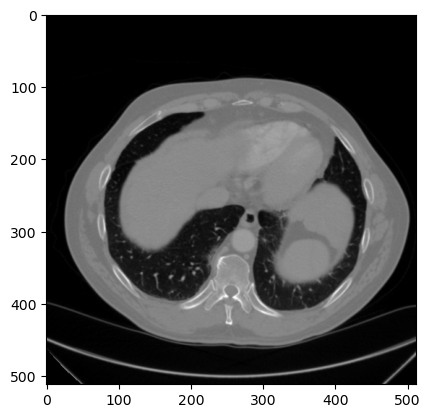

In [281]:
plt.imshow(im, vmin=-1000, vmax=1000, cmap="gray")
plt.show()

## Reading an image

In [282]:
# Directory containing data and images
in_dir = "example_images/"

# X-ray image
im_name = "witchun.png"

# Read the image.
# Here the directory and the image name is concatenated  by "+" to give the full path to the image.
im_org = io.imread(os.path.join(in_dir, im_name))
im_org.shape

(1280, 960, 3)

## Histogram

Max count: 35570.0 at: 99


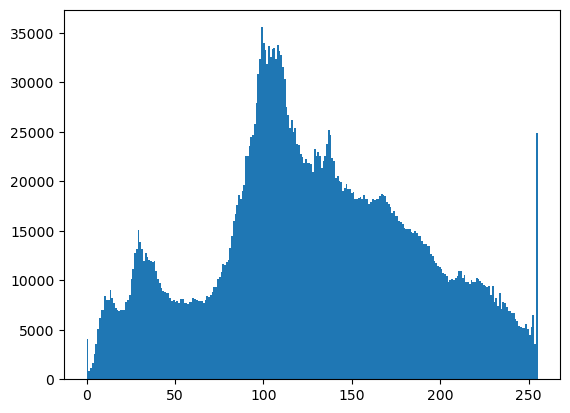

In [283]:
# Since the number of bins match the number of different intensities in the image, it may be confusing.
# Max_at represent the bin number, not the most common intensity (although in this case change).
# If you do not understand what I mean, Repeat this and exercise 9 using bin_no to 4 and reflect on the results.
nbins = 256
# h = plt.hist(im_org.ravel(), bins=nbins)
y, x, _ = plt.hist(im_org.ravel(), bins=nbins)
max_count = y.max()
max_at = y.argmax()
bin_no = 100
# count = h[0][bin_no]
# print(f"There are {count} pixel values in bin {bin_no}")
print(f"Max count: {max_count} at: {max_at}")

## Resize and rescale for fun

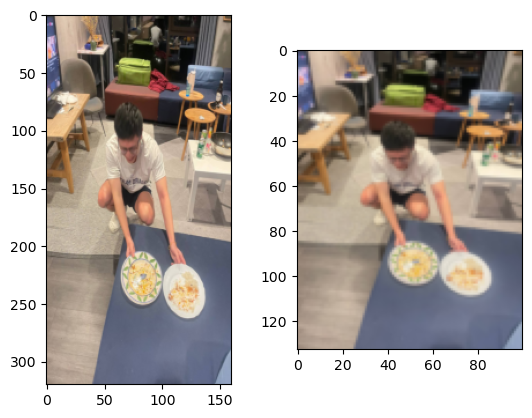

In [284]:
image_resized = resize(
    im_org, (im_org.shape[0] // 4, im_org.shape[1] // 6), anti_aliasing=True
)
_, c, _ = im_org.shape
rescale_factor = 100 / c
image_rescaled = rescale(im_org, rescale_factor, anti_aliasing=True, channel_axis=2)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(image_resized)
axes[1].imshow(image_rescaled)
plt.show()

## 

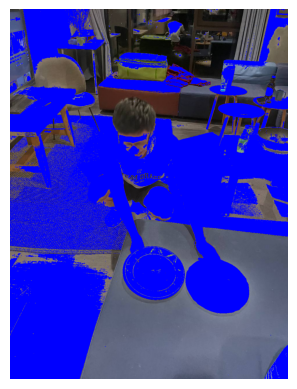

In [285]:
# Ensure the mask selects only the first channel for thresholding
mask = im_org[..., 0] > 140
im_masked = im_org.copy()
im_masked[mask] = [0, 0, 255]
plt.imshow(im_masked)
plt.axis('off')
plt.show()

## Trigonometry

In [286]:
import math

a, b = 10, 3
theta_rad = math.atan2(b, a)
theta_deg = theta_rad * 180 / math.pi

print(f"Angle (deg): {theta_deg}")

Angle (deg): 16.69924423399362


### Exercise 2

Create a Python function called `camera_b_distance`.

The function should accept two arguments, a focal length f and an
object distance g. It should return the distance from the lens to
where the rays are focused (b) (where the CCD should be placed)

The function should start like this:

```python
def camera_b_distance(f, g):
    """
    camera_b_distance returns the distance (b) where the CCD should be placed
    when the object distance (g) and the focal length (f) are given
    :param f: Focal length
    :param g: Object distance
    :return: b, the distance where the CCD should be placed
    """
```

It should be based on Gauss' lens equation:
$$\frac{1}{g} + \frac{1}{b} = \frac{1}{f}$$

You should decide if your function should calculate distances in mm or
in meters, but remember to be consistent!

Use your function to find out where the CCD should be placed when the
focal length is 15 mm and the object distance is 0.1, 1, 5, and 15
meters.

What happens to the place of the CCD when the object distance is increased?

In [287]:
def camera_b_distance(f, g):
    """
    camera_b_distance returns the distance (b) where the CCD should be placed
    when the object distance (g) and the focal length (f) are given
    :param f: Focal length
    :param g: Object distance
    :return: b, the distance where the CCD should be placed
    """
    b = 1 / (f ** (-1) - g ** -(1))
    return b

## Thresholding, pixel type conversions, histogram stretching in Week3

In [288]:
im_float = img_as_float(im_org)
min = im_float.min()
max = im_float.max()
print(f"Min value: {min} \t Max value: {max}")

# Can you verify that the float image is equal to the original image, where each pixel value is divided by 255?
all_equal = np.allclose(im_org, im_float * 255)
print(f"The float and the original image are equivalent?: {all_equal}")

Min value: 0.0 	 Max value: 1.0
The float and the original image are equivalent?: True


In [289]:
im_ubyte = img_as_ubyte(im_float)
min, max = im_ubyte.min(), im_ubyte.max()
print(f"Min value: {min} \t Max value: {max}")

Min value: 0 	 Max value: 255


In [290]:
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0

    # Do something here
    img_out = (
        (img_float - min_val) * (max_desired - min_desired) / (max_val - min_val)
    ) + min_desired
    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)

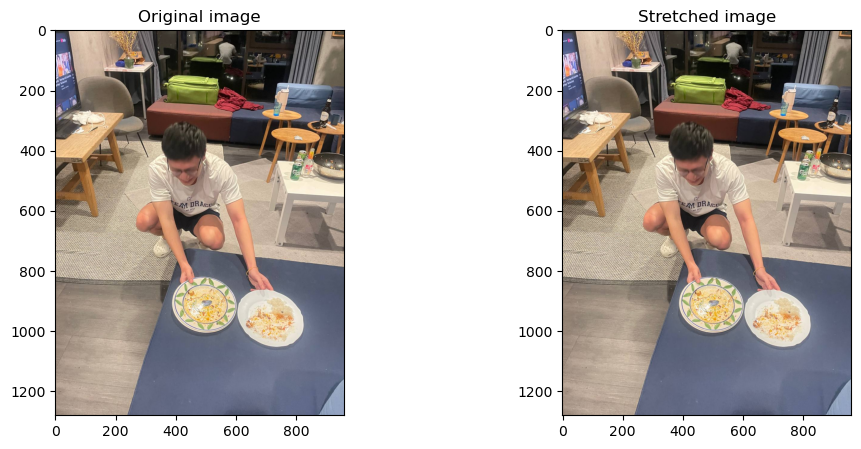

In [291]:
im_stretched = histogram_stretch(im_org)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ax[0].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original image")
ax[1].imshow(im_stretched, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Stretched image")
plt.show()

In [292]:
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0

    # Do something here
    img_out = (
        (img_float - min_val) * (max_desired - min_desired) / (max_val - min_val)
    ) + min_desired
    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)

In [293]:
def gamma_map(img_in, gamma):
    """
    Stretches the histogram of an image
    :param img_in: Input image
    :param gamma: Exponent
    :return: Gamma-mapped image
    """
    img_float = img_as_float(img_in)
    img_out = np.power(img_float, gamma)
    return img_as_ubyte(img_out)

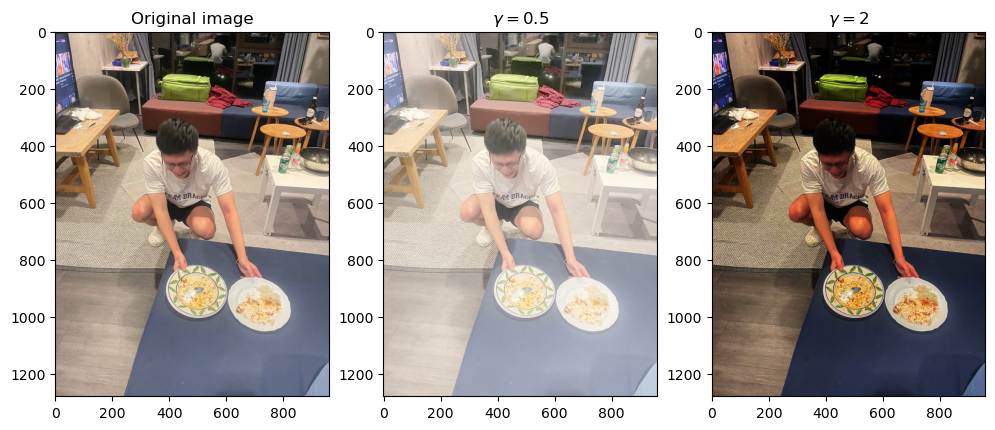

In [294]:
gamma_0_5 = gamma_map(im_org, 0.5)
gamma_2 = gamma_map(im_org, 2)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
ax[0].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original image")
ax[1].imshow(gamma_0_5, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(r"$\gamma = 0.5$")
ax[2].imshow(gamma_2, cmap="gray", vmin=0, vmax=255)
ax[2].set_title(r"$\gamma = 2$")
plt.show()

In [295]:
def threshold_image(img_in, thres):
    """
    Apply a threshold in an image and return the resulting image
    :param img_in: Input image
    :param thres: The treshold value in the range [0, 255]
    :return: Resulting image (unsigned byte) where background is 0 and foreground is 255
    """
    mask = img_in > thres
    return img_as_ubyte(mask)

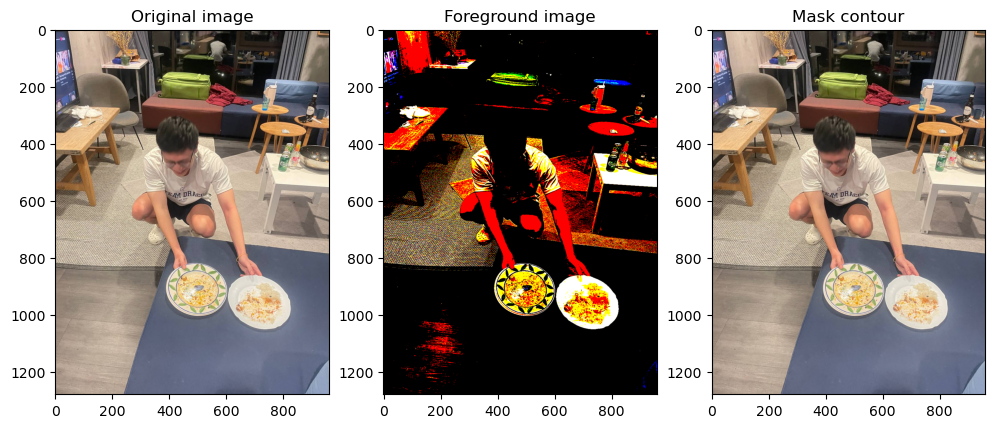

In [296]:
im_thres = threshold_image(im_org, thres=200)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
ax[0].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original image")
ax[1].imshow(im_thres, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Foreground image")
ax[2].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Mask contour")
plt.show()

/tmp/ipykernel_16495/4240897623.py:1: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (1280, 960, 3) looks like that of an RGB image.
  thres_new = threshold_otsu(im_org)


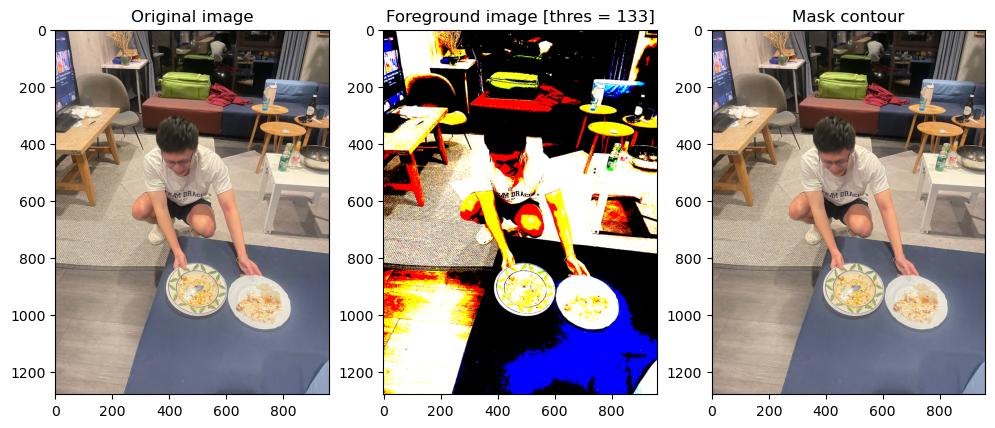

In [297]:
thres_new = threshold_otsu(im_org)
im_thres = threshold_image(im_org, thres=thres_new)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
ax[0].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original image")
ax[1].imshow(im_thres, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(f"Foreground image [thres = {thres_new}]")
ax[2].imshow(im_org, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Mask contour")
plt.show()

In [298]:
# def detect_dtu_signs(img_in, sign):
#     r_comp = img_in[:, :, 0]
#     g_comp = img_in[:, :, 1]
#     b_comp = img_in[:, :, 2]

#     if sign == "red":
#         segm = (
#             (r_comp > 160)
#             & (r_comp < 180)
#             & (g_comp > 50)
#             & (g_comp < 80)
#             & (b_comp > 50)
#             & (b_comp < 80)
#         )
#     if sign == "blue":
#         segm = (
#             (r_comp < 10)
#             & (g_comp > 85)
#             & (g_comp < 105)
#             & (b_comp > 180)
#             & (b_comp < 200)
#         )

## Correlation (kernel), Mean filter, median filter, gaussian filter, edge filter, edge detection in Week 4

In [299]:
def apply_median_filter(img, size):
    footprint = np.ones([size, size])
    med_img = median(img, footprint)
    return med_img

In [300]:
def apply_mean_filter(img, size):
    weights = np.ones([size, size])
    weights = weights / np.sum(weights)

    out_img = correlate(img, weights, mode="reflect")
    return out_img

In [301]:
size = 10
witchun_gray = rgb2gray(im_org)

witchun_mean = apply_mean_filter(witchun_gray, size)
witchun_median = apply_median_filter(witchun_gray, size)
witchun_gauss = gaussian(witchun_gray, size)

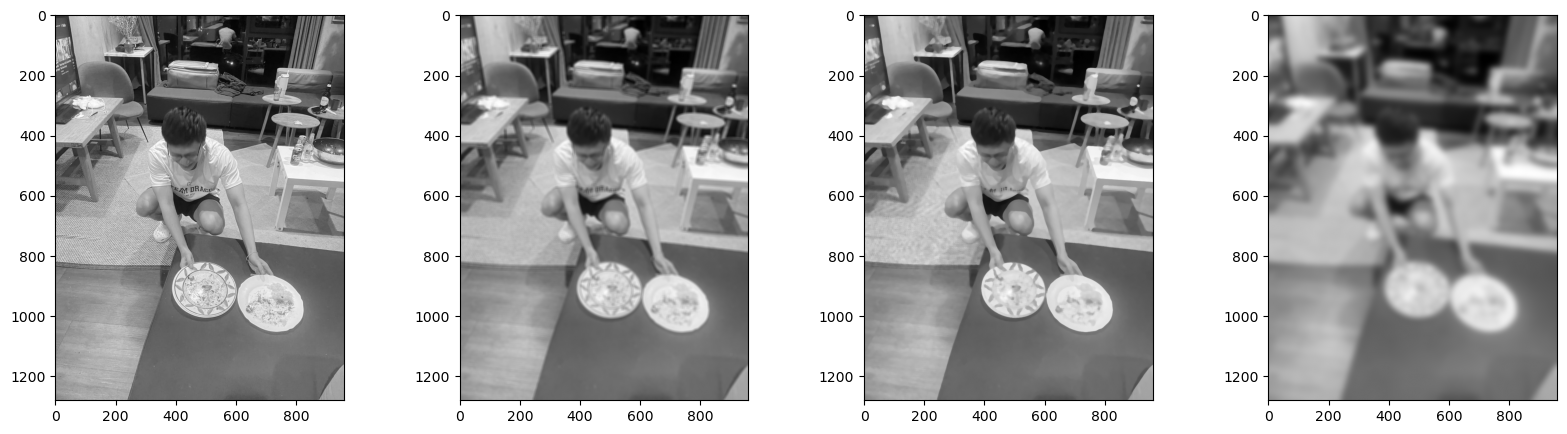

In [302]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
ax[0].imshow(witchun_gray, cmap="gray")
ax[1].imshow(witchun_mean, cmap="gray")
ax[2].imshow(witchun_median, cmap="gray")
ax[3].imshow(witchun_gauss, cmap="gray")
plt.show()

In [303]:
img_gray = rgb2gray(im_org)
img_h = prewitt_h(img_gray)
img_v = prewitt_v(img_gray)

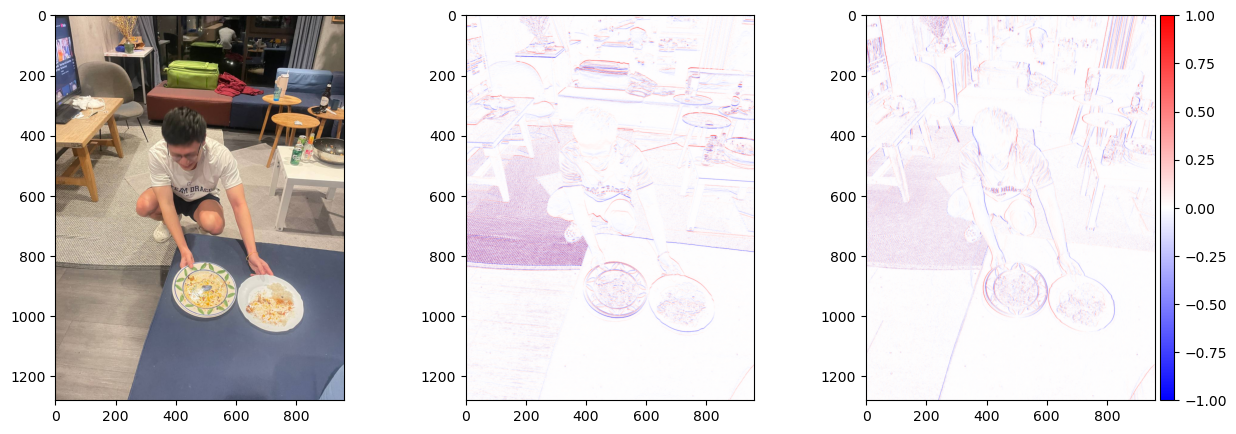

In [304]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax[0].imshow(im_org)
ax[1].imshow(img_h, cmap="bwr", vmin=-1, vmax=1)

im = ax[2].imshow(img_v, cmap="bwr", vmin=-1, vmax=1)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

plt.show()

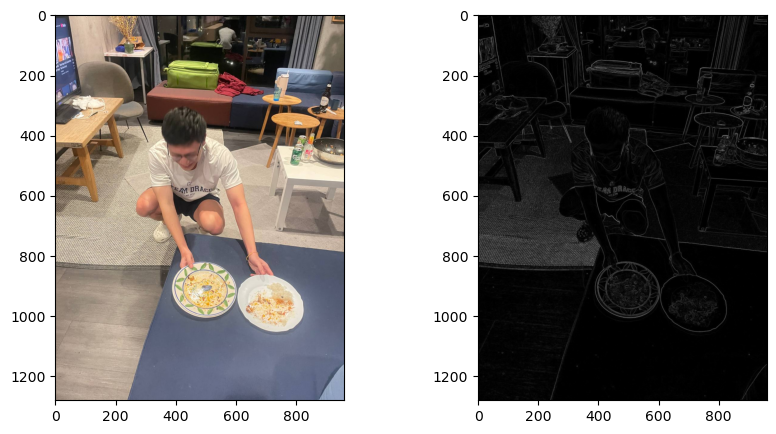

In [305]:
img_prewitt = prewitt(img_gray)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax[0].imshow(im_org)
ax[1].imshow(img_prewitt, cmap="gray", vmin=0, vmax=1)
plt.show()

In [306]:
def edge_detection(img, filter_type, kernel_size, thres, plot=False):
    """
    img: (2D ndarray)
    filter_type: (str) 'gaussian' or 'median'
    kernel_size: (int) size of the smoothing filter
    thres: (float) threshold for the binarization.
    plot: (bool) whether plot the images. Default False.
    """

    if filter_type == "gaussian":
        img_filt = gaussian(img, kernel_size)
    elif filter_type == "median":
        img_filt = apply_median_filter(img, kernel_size)

    # thres = threshold_otsu(img_filt) # Uncomment to use Otsu's method instead of manual thresholding

    gradients = prewitt(img_filt)
    edges = gradients > thres

    if plot:
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
        ax[0].imshow(img_filt, cmap="gray")
        ax[1].imshow(gradients, cmap="gray")
        ax[2].imshow(edges, cmap="gray")
        [ax_.set_axis_off() for ax_ in ax]
        plt.show()

    return edges

## Morphological operations and BLOB analysis

/tmp/ipykernel_16495/2540270616.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


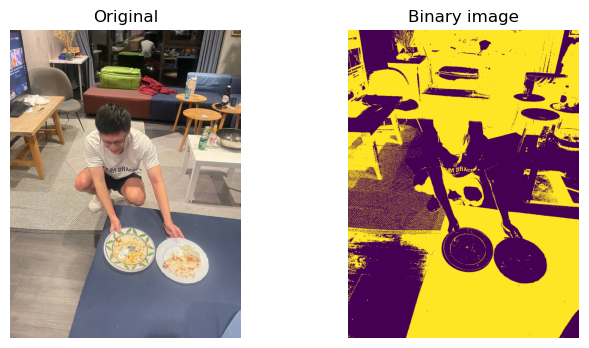

In [307]:
im_gray = color.rgb2gray(im_org)
thres = threshold_otsu(im_gray)
im_bin = im_gray < thres

show_comparison(im_org, im_bin, "Binary image")
im_process = segmentation.clear_border(im_bin)

In [308]:
footprint = morphology.disk(5)
im_process = morphology.binary_closing(im_process, footprint)
im_open = morphology.binary_opening(im_process, footprint)
label_img = measure.label(im_open)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")

Number of labels: 26


/tmp/ipykernel_16495/2540270616.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


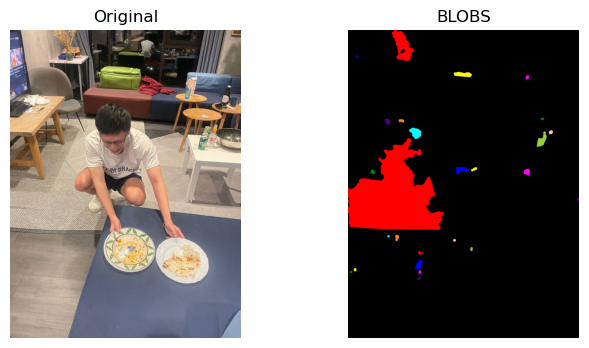

In [309]:
im_blob = label2rgb(label_img)
show_comparison(im_org, im_blob, "BLOBS")

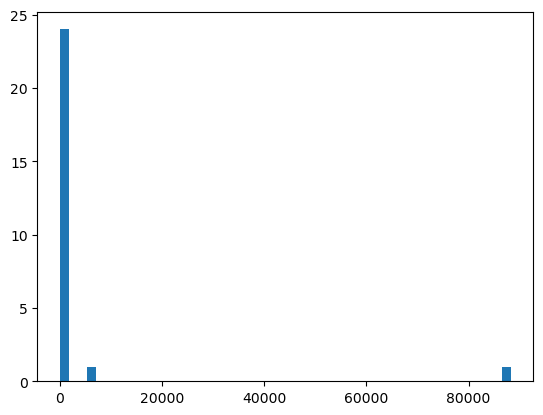

In [310]:
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()

In [311]:
min_area = 10
max_area = 150

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
    # Find the areas that do not fit our criteria
    if region.area > max_area or region.area < min_area:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0

In [312]:
def circularity(area, perimeter):
    """
    You may get values larger than 1 because
    we are in a "discrete" (pixels) domain. Check:

    CIRCULARITY OF OBJECTS IN IMAGES, Botterma, M.J. (2000)
    https://core.ac.uk/download/pdf/14946814.pdf
    """
    f_circ = (4 * np.pi * area) / (perimeter**2)
    return f_circ


In [313]:
min_circ = 0.7
min_area = 10
max_area = 150

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
    circ = circularity(region.area, region.perimeter)
    # Find the areas that do not fit our criteria
    if region.area > max_area or region.area < min_area or circ < min_circ:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0

# Create binary image from the filtered label image
i_area = label_img_filter > 0

In [314]:
def cell_counting(img_gray, min_area=10, max_area=150, min_circ=0.7):

    # Binarization
    thres = threshold_otsu(img_gray)
    img_bin = img_gray > thres
    img_c_b = segmentation.clear_border(img_bin)

    # Label image
    label_img = measure.label(img_c_b)

    # Extract properties
    region_props = measure.regionprops(label_img)

    # Number of blobs
    n_nuclei = len(region_props)

    # Filter the label image
    label_img_filter = label_img.copy()
    for region in region_props:
        circ = circularity(region.area, region.perimeter)
        # Find the areas that do not fit our criteria
        if region.area > max_area or region.area < min_area or circ < min_circ:
            # set the pixels in the invalid areas to background
            n_nuclei = n_nuclei - 1
            for cords in region.coords:
                label_img_filter[cords[0], cords[1]] = 0

    # Create binary image from the filtered label image
    i_area = label_img_filter > 0

    return i_area, n_nuclei

In [315]:
# # Step 3: BLOB analysis
# # Example flow
# labeled_img, num_blobs = label(binary_img)
# props = regionprops(labeled_img)

# # Compute area and perimeter for each BLOB
# blobs = []
# for prop in props:
#     area = prop.area  # Area in pixels
#     perimeter = prop.perimeter  # Perimeter in pixels
#     blobs.append(
#         {
#             "label": prop.label,
#             "area": area,
#             "perimeter": perimeter,
#             "centroid": prop.centroid,
#         }
#     )

# # Step 4: Filter BLOBs to identify kidneys
# # Assumption: Kidneys are among the largest BLOBs, roughly symmetric
# # Sort BLOBs by area (descending)
# blobs_sorted = sorted(blobs, key=lambda x: x["area"], reverse=True)

# # Heuristic: Select top 2 BLOBs with similar areas (e.g., within 50% of each other)
# # Example criteria (adjust based on data):
# min_area = 500  # Minimum area in pixels (tune based on resolution)
# max_area = 5000  # Maximum area in pixels
# kidney_blobs = []
# for blob in blobs_sorted:
#     if min_area <= blob["area"] <= max_area:
#         kidney_blobs.append(blob)
#     if len(kidney_blobs) == 2:
#         # Check if areas are reasonably similar
#         area1, area2 = kidney_blobs[0]["area"], kidney_blobs[1]["area"]
#         if abs(area1 - area2) / max(area1, area2) < 0.5:
#             break
#         else:
#             kidney_blobs.pop()  # Remove if not similar

# if len(kidney_blobs) != 2:
#     print("Warning: Could not identify exactly two kidneys.")

# # Create binary image with only kidney BLOBs
# kidney_mask = np.zeros_like(binary_img)
# for blob in kidney_blobs:
#     kidney_mask[labeled_img == blob["label"]] = 1

# # Step 5: Morphological closing
# structuring_element = disk(3)  # Disk with radius 3
# closed_img = closing(kidney_mask, structuring_element)

# # Optional: Visualize results
# plt.figure(figsize=(15, 5))
# plt.subplot(131)
# plt.title("Original Binary Image")
# plt.imshow(binary_img, cmap="gray")
# plt.subplot(132)
# plt.title("Kidney BLOBs")
# plt.imshow(kidney_mask, cmap="gray")
# plt.subplot(133)
# plt.title("After Morphological Closing")
# plt.imshow(closed_img, cmap="gray")
# plt.tight_layout()
# plt.show()

# # Optional: Save or return the final kidney mask
# # np.save("kidney_mask.npy", closed_img)

## Week 6 Hounsfield units, Gaussian Distribution on training pixels Look at wk 6 solutions on classification based on gaussians, theres too much to copy here

In [316]:
import pydicom as dicom
import numpy as np
# Extract pixel array
img = ds.pixel_array

# Convert to Hounsfield Units (HU) if necessary
try:
    rescale_slope = ds.RescaleSlope
    rescale_intercept = ds.RescaleIntercept
    img_hu = img * rescale_slope + rescale_intercept
except AttributeError:
    print("Warning: RescaleSlope/Intercept not found. Assuming pixel_array is in HU.")
    img_hu = img


# # Step 3: Compute median Hounsfield Unit for kidney pixels
# kidney_pixels = img_hu[closed_img == 1]
# if kidney_pixels.size > 0:
#     median_hu = np.median(kidney_pixels)
#     print(f"Median Hounsfield Unit for the kidneys: {median_hu:.2f} HU")
# else:
#     print("Error: No kidney pixels found in the mask.")

In [317]:
def get_gaussian_distributions(values, min_hu=-200, max_hu=1000):
    hu_range = np.arange(min_hu, max_hu, 1.0)
    mu = np.mean(values)
    std = np.std(values)
    pdf = norm.pdf(hu_range, mu, std)
    return pdf


def load_mask(mask_path):
    roi = io.imread(mask_path)
    mask = roi > 0
    return mask


def get_values(img, mask_path):
    mask = load_mask(mask_path)
    return img[mask]


# min_hu, max_hu = -200, 1000
# hu_range = np.arange(min_hu, max_hu, 1.0)
# paths = ["BoneROI.png", "FatROI.png", "KidneyROI.png", "LiverROI.png", "SpleenROI.png"]

# values = [get_values(img, in_dir + path) for path in paths]
# pdfs = [get_gaussian_distributions(value) for value in values]

# for pdf, path in zip(pdfs, paths):
#     plt.plot(hu_range, pdf, label=path)

# plt.title("Fitted Gaussians")
# plt.legend()
# plt.show()

In [318]:
# # Manual intersection Fat - Soft
# for pdf, path in zip(pdfs_3_classes, labels_3_classes):
#     plt.plot(hu_range, pdf, label=path)
# plt.title("Intersection Fat - Soft")
# plt.xlim(-45, -44)
# plt.ylim(0, 1e-7)
# plt.legend()
# plt.show()

# # Manual intersection  Soft - Bone
# for pdf, path in zip(pdfs_3_classes, labels_3_classes):
#     plt.plot(hu_range, pdf, label=path)

# plt.title("Intersection Soft - Bone")
# plt.xlim(138, 142)
# plt.ylim(0, 1e-8)
# plt.legend()
# plt.show()

In [319]:
# # This cell helps you to define an
# # interval for the intersection of the gaussians.
# # Just change the test_value and run the cell again

# mu_bone = np.mean(values_3_classes[0])
# std_bone = np.std(values_3_classes[0])

# mu_fat = np.mean(values_3_classes[1])
# std_fat = np.std(values_3_classes[1])

# mu_soft = np.mean(values_3_classes[2])
# std_soft = np.std(values_3_classes[2])

# # Soft vs Bone
# test_value = 140
# if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_bone, std_bone):
#     print(f"For value {test_value} the class is soft tissue")
# else:
#     print(f"For value {test_value} the class is bone")

# # Soft vs Fat
# test_value = -45
# if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_fat, std_fat):
#     print(f"For value {test_value} the class is soft tissue")
# else:
#     print(f"For value {test_value} the class is fat")

## LDA: See the full ex6b

In [320]:
import numpy as np


def LDA(X, y):
    """
    Linear Discriminant Analysis.

    A classifier with a linear decision boundary, generated by fitting class conditional densities to the data and using Bayes’ rule.
    Assumes equal priors among classes

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Training data
    y : array-like of shape (n_samples,)
        Target values.

    Returns
    -------
    W : array-like of shape (n_classes, n_features+1)
        Weights for making the projection. First column is the constants.

    Last modified: 11/11/22, mcbo@dtu.dk
    """

    # Determine size of input data
    n, m = X.shape
    # Discover and count unique class labels
    class_label = np.unique(y)
    k = len(class_label)

    # Initialize
    n_group = np.zeros((k, 1))  # Group counts
    group_mean = np.zeros((k, m))  # Group sample means
    pooled_cov = np.zeros((m, m))  # Pooled covariance
    W = np.zeros((k, m + 1))  # Model coefficients

    for i in range(k):
        # Establish location and size of each class
        group = np.squeeze(y == class_label[i])
        n_group[i] = np.sum(group.astype(np.double))

        # Calculate group mean vectors
        group_mean[i, :] = np.mean(X[group, :], axis=0)

        # Accumulate pooled covariance information
        pooled_cov = pooled_cov + ((n_group[i] - 1) / (n - k)) * np.cov(
            X[group, :], rowvar=False
        )

    # Assign prior probabilities
    prior_prob = n_group / n

    # Loop over classes to calculate linear discriminant coefficients
    for i in range(k):
        # Intermediate calculation for efficiency
        temp = group_mean[i, :][np.newaxis] @ np.linalg.inv(pooled_cov)

        # Constant
        W[i, 0] = -0.5 * temp @ group_mean[i, :].T + np.log(prior_prob[i])

        # Linear
        W[i, 1:] = temp

    return W

## Ex7 playing with rotations and landmarks

## Ex 8 PCA